# Problem 3.3

## Data

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# download 3 years worth of data
data = yf.download('^GSPC', start='2020-01-01', end='2023-01-01')
prices = data['Close'].dropna()

prices.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2020-01-02,3257.850098
2020-01-03,3234.850098
2020-01-06,3246.280029
2020-01-07,3237.179932
2020-01-08,3253.050049


## ARIMA model

ADF test
p-value: 0.5235


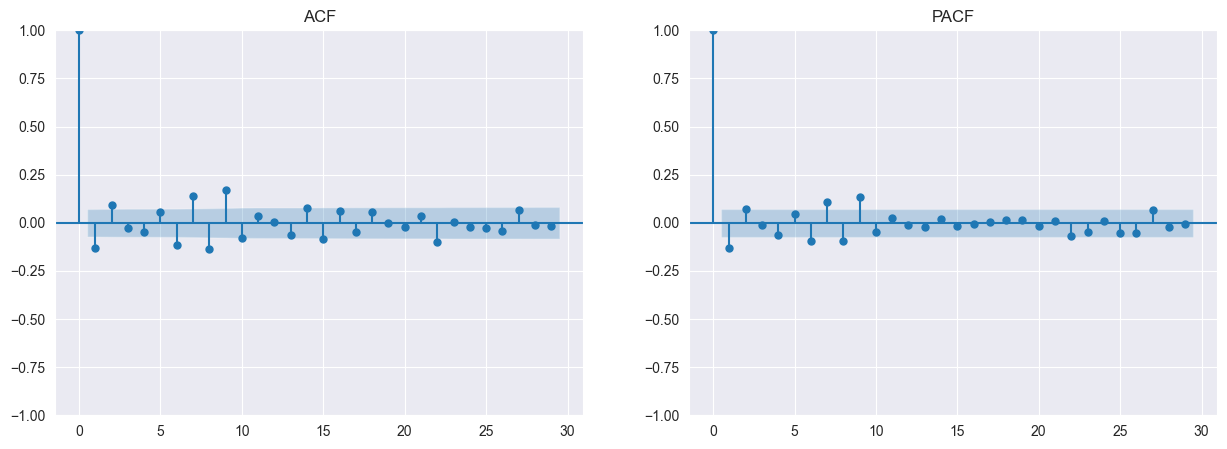

C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\zawer\documents\applied_math\se

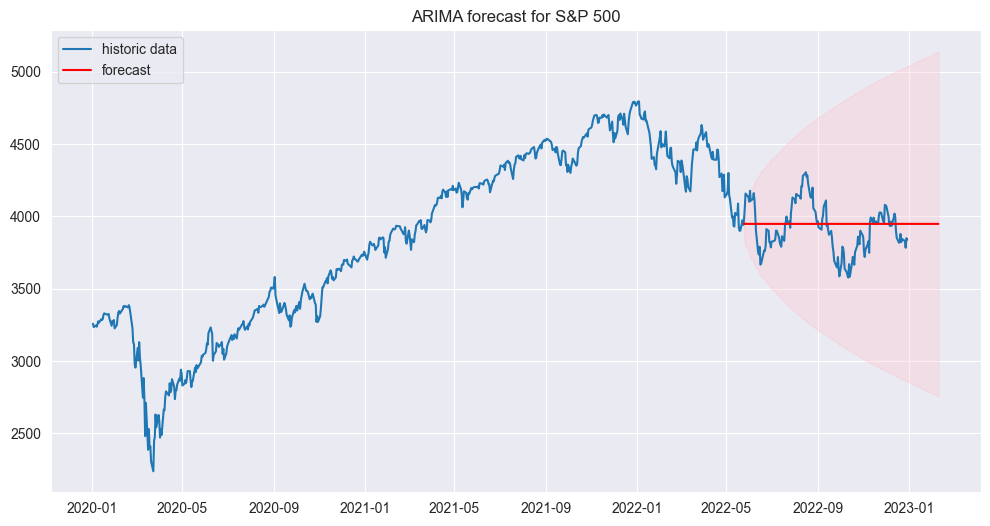

                               SARIMAX Results                                
Dep. Variable:                  ^GSPC   No. Observations:                  604
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3232.788
Date:                Sun, 26 Apr 2026   AIC                           6471.575
Time:                        18:10:54   BIC                           6484.781
Sample:                             0   HQIC                          6476.715
                                - 604                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4842      0.091     -5.297      0.000      -0.663      -0.305
ma.L1          0.2994      0.100      2.981      0.003       0.103       0.496
sigma2      2655.5719     89.518     29.665      0.0

In [6]:
# ADF test
print("ADF test")
adf_result = adfuller(prices)
print(f"p-value: {adf_result[1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(prices.diff().dropna(), ax=ax1, title="ACF")
plot_pacf(prices.diff().dropna(), ax=ax2, title="PACF")
plt.show()

# split into test and train
split = int(len(prices) * 0.8)
train_prices, test_prices = prices.iloc[:split], prices.iloc[split:]

# fit ARIMA
model_arima = ARIMA(train_prices, order=(1, 1, 1))
res_arima = model_arima.fit()

# forecast
forecast_steps = len(test_prices) + 30
forecast_obj = res_arima.get_forecast(steps=forecast_steps)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

future_dates = pd.bdate_range(start=test_prices.index[-1] + pd.Timedelta(days=1), periods=30)
forecast_dates = test_prices.index.append(future_dates)

forecast_mean.index = forecast_dates
conf_int.index = forecast_dates

plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices, label='historic data')
plt.plot(forecast_mean.index, forecast_mean, color='red', label='forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('ARIMA forecast for S&P 500')
plt.legend()
plt.show()

print(res_arima.summary())

# Problem 3.4

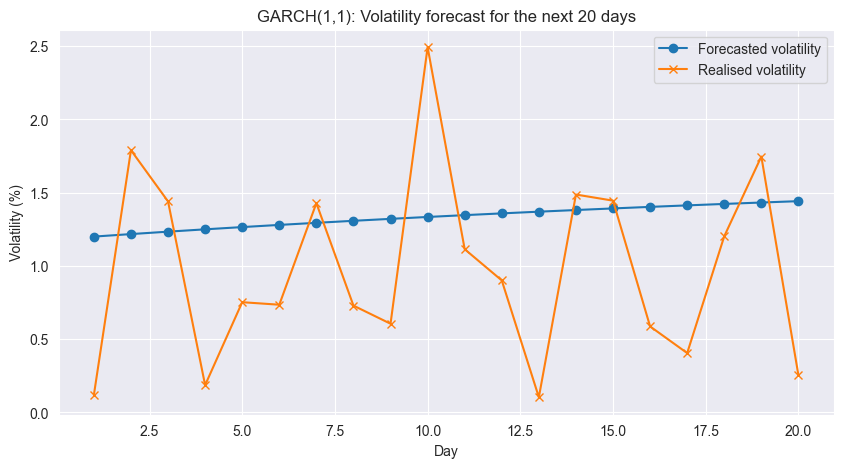

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1225.92
Distribution:                  Normal   AIC:                           2459.84
Method:            Maximum Likelihood   BIC:                           2478.34
                                        No. Observations:                  755
Date:                Sun, Apr 26 2026   Df Residuals:                      754
Time:                        18:10:56   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0797  3.814e-02      2.090  3.665e-02 [4.947e-0

In [7]:
# calculating log-returns (*100 for better stability)
returns = prices.pct_change().dropna() * 100

# fitting GARCH(1,1)
model_garch = arch_model(returns, vol='Garch', p=1, q=1)
res_garch = model_garch.fit(disp='off')

# forecast for the next 20 days
forecast_garch = res_garch.forecast(horizon=20)
# calculating volatility
pred_vol = np.sqrt(forecast_garch.variance.values[-1, :])

# validation using realized volatility
realized_vol = np.abs(returns[-20:])

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), pred_vol, marker='o', label='Forecasted volatility')
plt.plot(range(1, 21), realized_vol.values, marker='x', label='Realised volatility')
plt.title('GARCH(1,1): Volatility forecast for the next 20 days')
plt.xlabel('Day')
plt.ylabel('Volatility (%)')
plt.legend()
plt.show()

print(res_garch.summary())